In [5]:
# Cell 1: Setup, load provider-level dataset, prepare X and y, train/val/test split
import os, sys
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

# Try to locate an in-memory provider DataFrame or load from common CSV paths
provider_df = None
for var in [ "final_provider_dataset_from_EDA"]:
    if var in globals():
        provider_df = globals()[var]
        print(f"Using in-memory dataframe: {var}")
        break

if provider_df is None:
    candidates = [
        "final_provider_dataset_from_EDA.csv"
    ]
    for p in candidates:
        if os.path.exists(p):
            provider_df = pd.read_csv(p)
            print("Loaded provider-level dataset from:", p)
            break

if provider_df is None:
    raise FileNotFoundError("Provider-level dataset not found. Create 'final_provider_df' or place CSV in data/")

print("Provider-level shape:", provider_df.shape)
display(provider_df.head(3))

# Identify label column
label_candidates = [c for c in provider_df.columns if c.lower() in ["fraud","fraud_bin","is_fraud","label","target"]]
if not label_candidates:
    label_candidates = [c for c in provider_df.columns if "fraud" in c.lower() or "target" in c.lower()]
if not label_candidates:
    raise ValueError("No label column found in provider-level dataset.")
label_col = label_candidates[0]
print("Using label column:", label_col)

# Prepare y (binary 0/1)
y = provider_df[label_col].copy()
if y.dtype == object:
    y = y.map(lambda v: 1 if str(v).strip().lower() in ["1","yes","y","true","fraud","fraudulent"] else 0)
else:
    y = y.astype(int)

# Prepare X: drop label and ID-like columns
X = provider_df.drop(columns=[label_col], errors='ignore').copy()
for c in ["Provider","provider","provider_id","id","index"]:
    if c in X.columns: X.drop(columns=[c], inplace=True)

# Encode non-numeric columns with LabelEncoder as a simple fallback (prefer better encoding if you have categorical features)
non_num = X.select_dtypes(include=['object','category']).columns.tolist()
if non_num:
    from sklearn.preprocessing import LabelEncoder
    for col in non_num:
        try:
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))
        except Exception:
            X.drop(columns=[col], inplace=True)

# Keep numeric columns only and fill missing values (simple strategy for modeling notebook)
X = X.select_dtypes(include=[np.number]).fillna(0)
print("Feature matrix shape:", X.shape)

# Stratified train/validation/test split: 60/20/20
from sklearn.model_selection import train_test_split
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)
print("Train/Val/Test shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Train class ratio:", y_train.mean(), "Val ratio:", y_val.mean(), "Test ratio:", y_test.mean())


Loaded provider-level dataset from: final_provider_dataset_from_EDA.csv
Provider-level shape: (5392, 73)


,Provider,in_InscClaimAmtReimbursed_mean,in_InscClaimAmtReimbursed_std,in_InscClaimAmtReimbursed_sum,in_InscClaimAmtReimbursed_median,in_DeductibleAmtPaid_mean,in_DeductibleAmtPaid_std,in_DeductibleAmtPaid_sum,in_DeductibleAmtPaid_median,in_ClmProcedureCode_1_mean,...,out_ClmProcedureCode_6_median,out_DeductibleAmtPaid_mean,out_DeductibleAmtPaid_std,out_DeductibleAmtPaid_sum,out_DeductibleAmtPaid_median,claims_count.1,unique_benes.1,claims_per_bene.1,num_unique_benes,PotentialFraud
0,PRV51001,19400.000000,18352.111595,97000.0,12000.0,1068.0,0.0,5340.0,1068.0,6090.000000,...,0.0,0.000000,0.000000,0.0,0.0,19.0,18.0,1.055556,23,No
1,PRV51003,9241.935484,8513.606244,573000.0,7000.0,1068.0,0.0,66216.0,1068.0,5460.846154,...,0.0,1.093750,8.750000,70.0,0.0,64.0,60.0,1.066667,111,Yes
2,PRV51007,6333.333333,3511.884584,19000.0,6000.0,1068.0,0.0,3204.0,1068.0,8627.000000,...,0.0,1.052632,6.730583,60.0,0.0,57.0,47.0,1.212766,49,No


Using label column: PotentialFraud
Feature matrix shape: (5392, 71)
Train/Val/Test shapes: (3234, 71) (1079, 71) (1079, 71)
Train class ratio: 0.09400123685837972 Val ratio: 0.09360518999073215 Test ratio: 0.09360518999073215


In [6]:
# Cell 2: Define candidate models and check imblearn availability
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "RandomForest": RandomForestClassifier(random_state=42, n_estimators=200, class_weight='balanced', n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42, n_estimators=200, learning_rate=0.1, max_depth=3),
    "LogisticRegression": LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000, solver='liblinear'),
    "SVM_RBF": Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', probability=True, class_weight='balanced'))])
}

print("Models defined:", list(models.keys()))

# Check SMOTE availability
use_smote = False
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    use_smote = True
    print("imblearn available: SMOTE will be used as an alternate strategy.")
except Exception:
    print("imblearn not installed — SMOTE experiments will be skipped. Install imbalanced-learn to enable oversampling.")


Models defined: ['DecisionTree', 'RandomForest', 'GradientBoosting', 'LogisticRegression', 'SVM_RBF']
imblearn available: SMOTE will be used as an alternate strategy.


In [13]:
# Cell 3: Evaluation utilities: metrics, PR/ROC plots, confusion matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

def compute_metrics(y_true, y_pred, y_proba):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_true, y_proba) if len(np.unique(y_true))>1 else np.nan
    roc_auc = roc_auc_score(y_true, y_proba) if len(np.unique(y_true))>1 else np.nan
    return {"precision": precision, "recall": recall, "f1": f1, "pr_auc": pr_auc, "roc_auc": roc_auc}


def plot_pr_roc_conf(y_true, y_proba, y_pred, title_prefix="Model"):
    # PR curve
    p, r, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba) if len(np.unique(y_true))>1 else np.nan
    plt.figure(figsize=(6,4))
    plt.plot(r, p, label=f"AP={ap:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"{title_prefix} — Precision-Recall"); plt.legend(); plt.grid(True); plt.show()
    # ROC curve
    if len(np.unique(y_true))>1:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
        plt.plot([0,1],[0,1],"--", color="grey")
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"{title_prefix} — ROC"); plt.legend(); plt.grid(True); plt.show()
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"{title_prefix} — Confusion Matrix"); plt.show()




Training (class_weight strategy): DecisionTree
DecisionTree {'precision': 0.48672566371681414, 'recall': 0.5445544554455446, 'f1': 0.514018691588785, 'pr_auc': np.float64(0.30768069548513327), 'roc_auc': np.float64(0.742624875984531)}


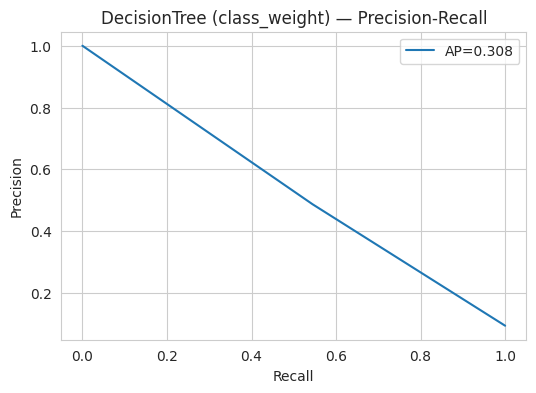

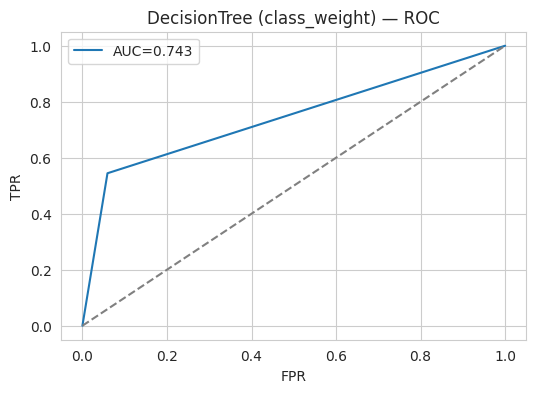

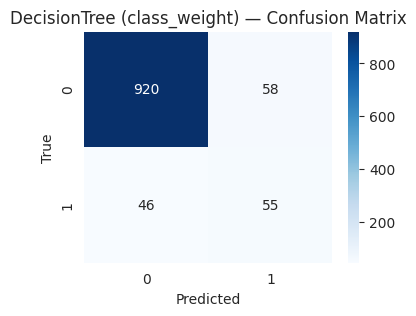

Training (class_weight strategy): RandomForest
RandomForest {'precision': 0.7454545454545455, 'recall': 0.40594059405940597, 'f1': 0.5256410256410257, 'pr_auc': np.float64(0.6670965885950124), 'roc_auc': np.float64(0.934874162262852)}


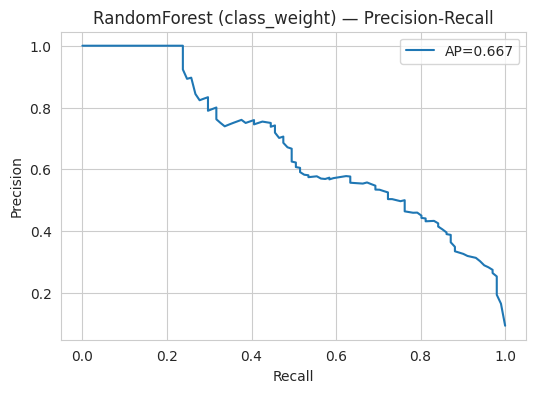

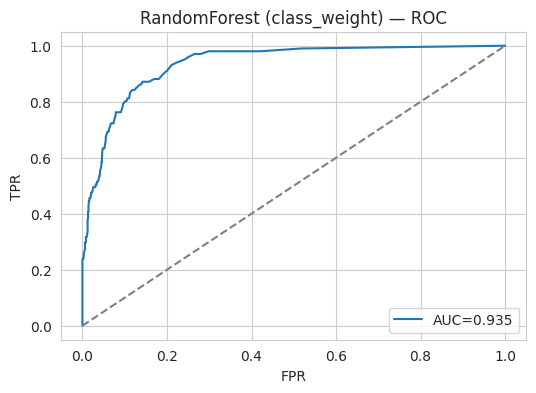

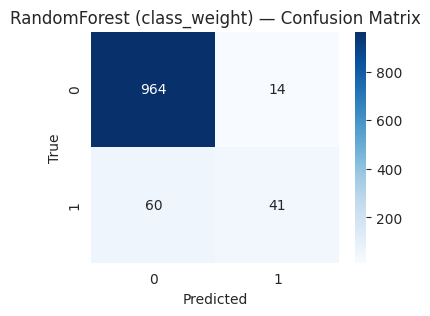

Training (class_weight strategy): GradientBoosting
GradientBoosting {'precision': 0.6923076923076923, 'recall': 0.44554455445544555, 'f1': 0.5421686746987951, 'pr_auc': np.float64(0.6804572591109245), 'roc_auc': np.float64(0.9324849662880397)}


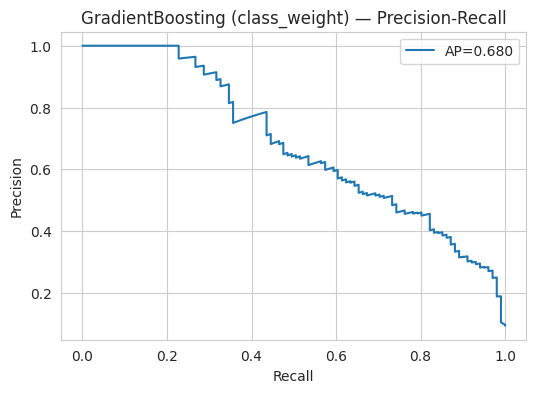

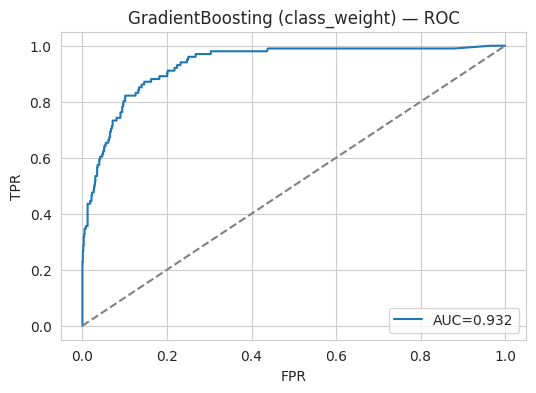

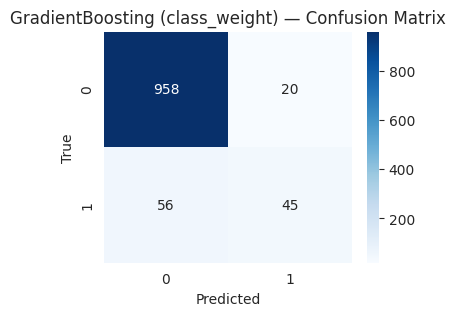

Training (class_weight strategy): LogisticRegression
LogisticRegression {'precision': 0.298932384341637, 'recall': 0.8316831683168316, 'f1': 0.4397905759162304, 'pr_auc': np.float64(0.627290359765795), 'roc_auc': np.float64(0.8845289436919153)}


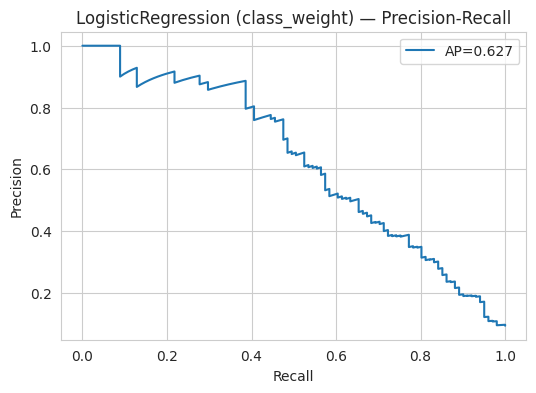

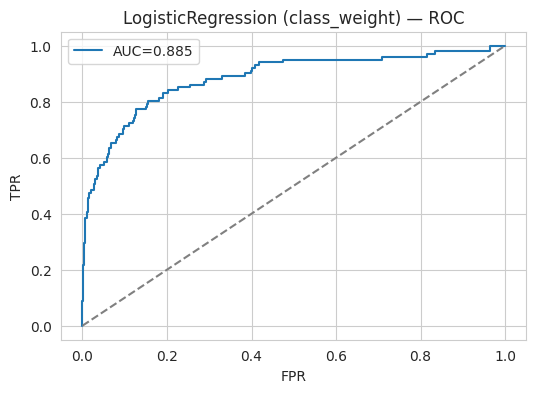

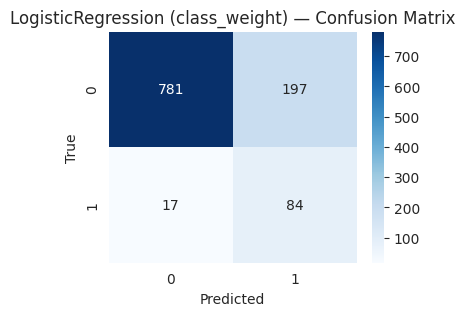

Training (class_weight strategy): SVM_RBF
SVM_RBF {'precision': 0.3662551440329218, 'recall': 0.8811881188118812, 'f1': 0.5174418604651163, 'pr_auc': np.float64(0.45504685309590026), 'roc_auc': np.float64(0.9110733159205491)}


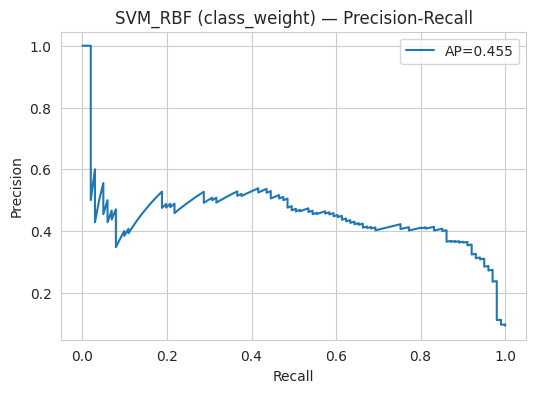

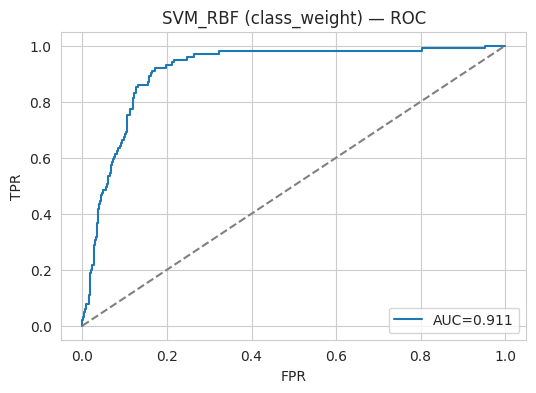

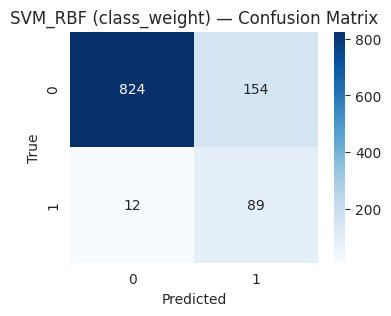

In [9]:
# Cell 4: Baseline evaluation with class_weight (train on X_train, evaluate on X_val)
import copy
baseline_results = []

for name, model in models.items():
    print("Training (class_weight strategy):", name)
    m = copy.deepcopy(model)
    try:
        m.fit(X_train, y_train)
    except Exception as e:
        print(f"Training error for {name}: {e}")
        continue
    # predict and proba
    if hasattr(m, "predict_proba"):
        y_val_proba = m.predict_proba(X_val)[:,1]
    else:
        try:
            y_val_proba = m.decision_function(X_val)
            y_val_proba = (y_val_proba - y_val_proba.min())/(y_val_proba.max()-y_val_proba.min()+1e-12)
        except Exception:
            y_val_proba = np.zeros(len(X_val))
    y_val_pred = m.predict(X_val)
    metrics = compute_metrics(y_val, y_val_pred, y_val_proba)
    baseline_results.append({"model": name, "strategy": "class_weight", **metrics})
    print(name, metrics)
    plot_pr_roc_conf(y_val, y_val_proba, y_val_pred, title_prefix=f"{name} (class_weight)")


Training with SMOTE: DecisionTree
DecisionTree {'precision': 0.3841059602649007, 'recall': 0.5742574257425742, 'f1': 0.4603174603174603, 'pr_auc': np.float64(0.2604274145046111), 'roc_auc': np.float64(0.7395827006013485)}


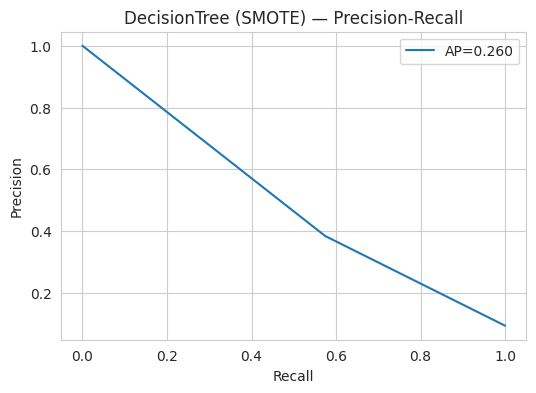

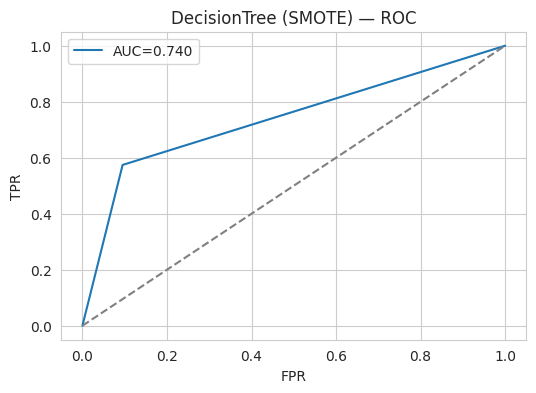

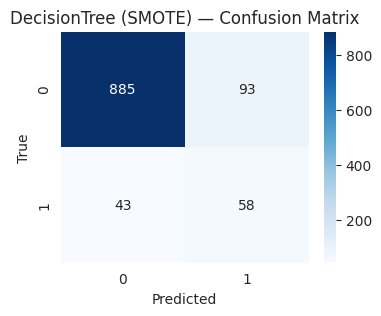

Training with SMOTE: RandomForest
RandomForest {'precision': 0.5403225806451613, 'recall': 0.6633663366336634, 'f1': 0.5955555555555555, 'pr_auc': np.float64(0.6294355540180773), 'roc_auc': np.float64(0.9301666362955313)}


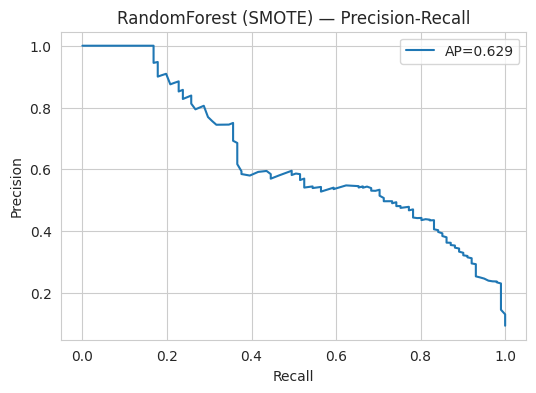

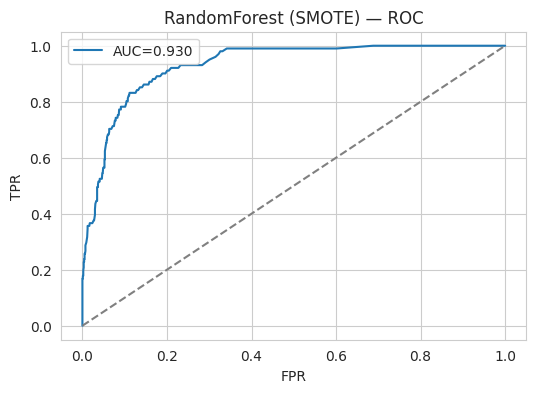

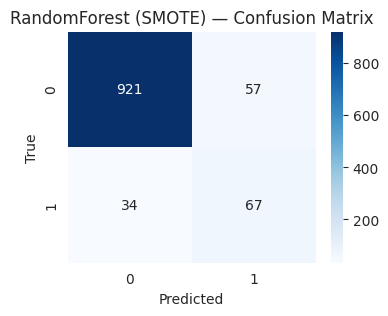

Training with SMOTE: GradientBoosting
GradientBoosting {'precision': 0.52, 'recall': 0.6435643564356436, 'f1': 0.5752212389380531, 'pr_auc': np.float64(0.6192743202454087), 'roc_auc': np.float64(0.9256514608516067)}


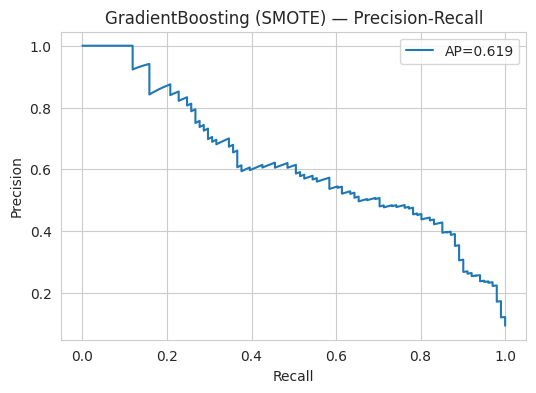

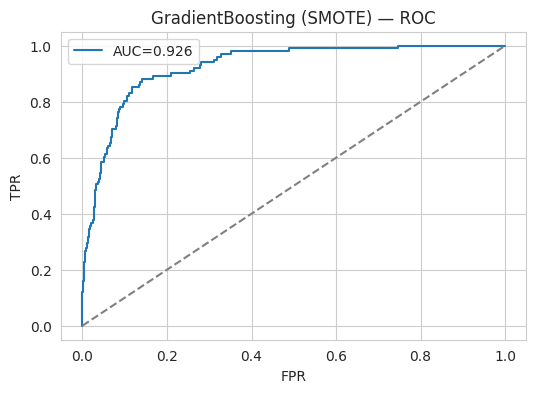

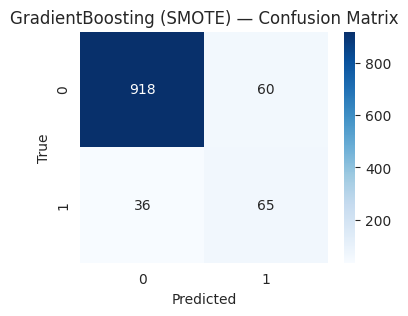

Training with SMOTE: LogisticRegression
LogisticRegression {'precision': 0.31203007518796994, 'recall': 0.8217821782178217, 'f1': 0.45231607629427795, 'pr_auc': np.float64(0.631710699957096), 'roc_auc': np.float64(0.8838506550041507)}


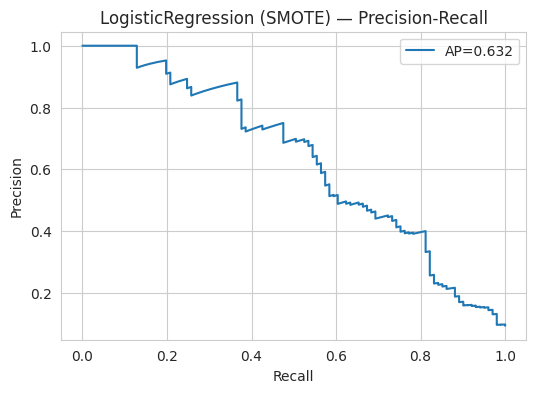

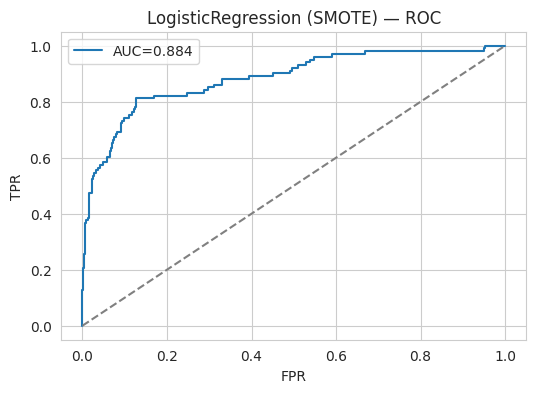

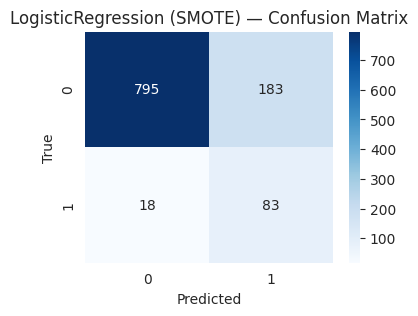

Training with SMOTE: SVM_RBF
SVM_RBF {'precision': 0.36909871244635195, 'recall': 0.8514851485148515, 'f1': 0.5149700598802395, 'pr_auc': np.float64(0.49758440482381866), 'roc_auc': np.float64(0.9056115734272814)}


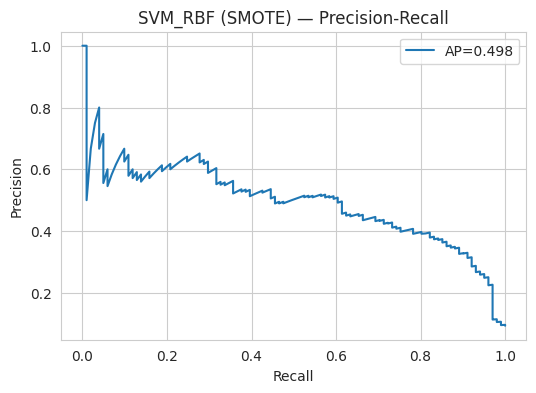

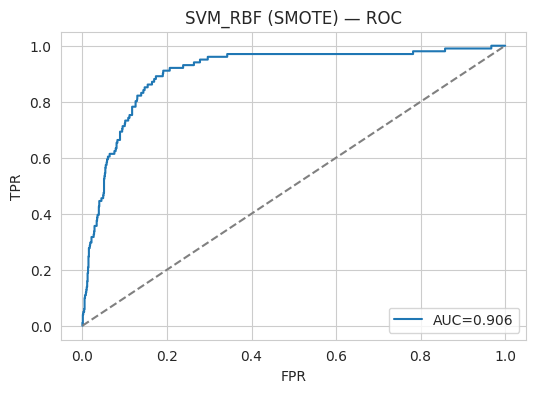

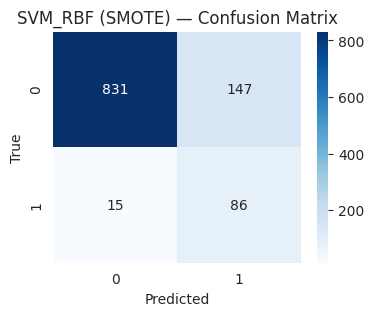

In [14]:
# Cell 5: SMOTE experiments (only on training data) — evaluate on the same validation set
smote_results = []
if use_smote:
    from imblearn.over_sampling import SMOTE
    for name, model in models.items():
        print("Training with SMOTE:", name)
        try:
            sm = SMOTE(random_state=42)
            X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
            m = copy.deepcopy(model)
            m.fit(X_train_sm, y_train_sm)
            if hasattr(m, "predict_proba"):
                y_val_proba = m.predict_proba(X_val)[:,1]
            else:
                try:
                    y_val_proba = m.decision_function(X_val)
                    y_val_proba = (y_val_proba - y_val_proba.min())/(y_val_proba.max()-y_val_proba.min()+1e-12)
                except Exception:
                    y_val_proba = np.zeros(len(X_val))
            y_val_pred = m.predict(X_val)
            metrics = compute_metrics(y_val, y_val_pred, y_val_proba)
            smote_results.append({"model": name, "strategy": "SMOTE", **metrics})
            print(name, metrics)
            plot_pr_roc_conf(y_val, y_val_proba, y_val_pred, title_prefix=f"{name} (SMOTE)")
        except Exception as e:
            print("SMOTE error for", name, e)
else:
    print("SMOTE not available; skipping oversampling experiments.")


In [16]:
# Cell 7: Collect and compare all results, evaluate best candidates on test set if not already
all_results = []

# Baseline class_weight models evaluated on validation — move them to test for final comparison
# retrain on train+val and evaluate on test for final metrics
for rec in baseline_results:
    name = rec['model']
    print("Retraining and evaluating (final) model:", name)
    m = copy.deepcopy(models[name])
    m.fit(X_trainval, y_trainval)
    if hasattr(m, "predict_proba"):
        y_test_proba = m.predict_proba(X_test)[:,1]
    else:
        try:
            y_test_proba = m.decision_function(X_test)
            y_test_proba = (y_test_proba - y_test_proba.min())/(y_test_proba.max()-y_test_proba.min()+1e-12)
        except Exception:
            y_test_proba = np.zeros(len(X_test))
    y_test_pred = m.predict(X_test)
    metrics_test = compute_metrics(y_test, y_test_pred, y_test_proba)
    all_results.append({"model": name, "strategy": "class_weight", **metrics_test})
    print(name, metrics_test)

# SMOTE final evaluations (if applicable)
if use_smote:
    for rec in smote_results:
        name = rec['model']
        print("Retraining on SMOTE (train+val) and evaluating:", name)
        sm = SMOTE(random_state=42)
        X_trainval_sm, y_trainval_sm = sm.fit_resample(X_trainval, y_trainval)
        m = copy.deepcopy(models[name])
        m.fit(X_trainval_sm, y_trainval_sm)
        if hasattr(m, "predict_proba"):
            y_test_proba = m.predict_proba(X_test)[:,1]
        else:
            try:
                y_test_proba = m.decision_function(X_test)
                y_test_proba = (y_test_proba - y_test_proba.min())/(y_test_proba.max()-y_test_proba.min()+1e-12)
            except Exception:
                y_test_proba = np.zeros(len(X_test))
        y_test_pred = m.predict(X_test)
        metrics_test = compute_metrics(y_test, y_test_pred, y_test_proba)
        all_results.append({"model": name, "strategy": "SMOTE", **metrics_test})
        print(name, metrics_test)

# Add tuned models' test metrics from tune_results
for rec in tune_results:
    all_results.append(rec)

# Consolidate into DataFrame and sort by PR-AUC (preferred metric for imbalanced)
results_df = pd.DataFrame(all_results)
if not results_df.empty:
    results_df = results_df.sort_values(by='pr_auc', ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv("model_comparison_final_results.csv", index=False)
print("Saved model comparison results to model_comparison_final_results.csv")


Retraining and evaluating (final) model: DecisionTree
DecisionTree {'precision': 0.5052631578947369, 'recall': 0.4752475247524752, 'f1': 0.4897959183673469, 'pr_auc': np.float64(0.2892446202817443), 'roc_auc': np.float64(0.7135951325193869)}
Retraining and evaluating (final) model: RandomForest
RandomForest {'precision': 0.8, 'recall': 0.43564356435643564, 'f1': 0.5641025641025641, 'pr_auc': np.float64(0.7186391523654433), 'roc_auc': np.float64(0.9501710907287048)}
Retraining and evaluating (final) model: GradientBoosting
GradientBoosting {'precision': 0.7432432432432432, 'recall': 0.5445544554455446, 'f1': 0.6285714285714286, 'pr_auc': np.float64(0.6906292607351767), 'roc_auc': np.float64(0.9435046265362732)}
Retraining and evaluating (final) model: LogisticRegression
LogisticRegression {'precision': 0.3474903474903475, 'recall': 0.8910891089108911, 'f1': 0.5, 'pr_auc': np.float64(0.6871917182045612), 'roc_auc': np.float64(0.9307335641539614)}
Retraining and evaluating (final) model: 

,model,strategy,precision,recall,f1,pr_auc,roc_auc
0,RandomForest,class_weight,0.800000,0.435644,0.564103,0.718639,0.950171
1,GradientBoosting,class_weight,0.743243,0.544554,0.628571,0.690629,0.943505
2,LogisticRegression,class_weight,0.347490,0.891089,0.500000,0.687192,0.930734
3,GradientBoosting,SMOTE,0.583333,0.762376,0.660944,0.686657,0.942406
4,LogisticRegression,SMOTE,0.376033,0.900990,0.530612,0.685488,0.929762
5,RandomForest,SMOTE,0.577236,0.702970,0.633929,0.680604,0.945747
6,SVM_RBF,SMOTE,0.406250,0.900990,0.560000,0.617956,0.942867
7,SVM_RBF,class_weight,0.395652,0.900990,0.549849,0.571399,0.939374
8,DecisionTree,class_weight,0.505263,0.475248,0.489796,0.289245,0.713595
9,DecisionTree,SMOTE,0.385542,0.633663,0.479401,0.278595,0.764684


Saved model comparison results to model_comparison_final_results.csv
